<h2>Sub-Question 1 Python Encapsulator, the Hypothesis and Analysis</h2>

Author: Resia S. Kilic

In [1]:
!pip install psycopg2-binary pandas matplotlib scipy

   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 19.7 MB/s  0:00:00
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ------ --------------------------------- 5.5/36.6 MB 26.5 MB/s eta 0:00:02
   --------------- ------------------------ 14.2/36.6 MB 34.5 MB/s eta 0:00:01
   -------------------------- ------------- 24.1/36.6 MB 38.6 MB/s eta 0:00:01
   -------------------------------- ------- 30.1/36.6 MB 35.6 MB/s eta 0:00:01
   ---------------------------------------  36.4/36.6 MB 36.9 MB/s eta 0:00:01
   ---------------------------------------- 36.6/36.6 MB 31.8 MB/s  0:00:01

   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   ---------------------------------

In [3]:
!pip install psycopg[binary]

   ---------------------------------------- 0.0/3.7 MB ? eta -:--:--
   ---------------------------------------- 3.7/3.7 MB 31.7 MB/s  0:00:00

   ---------------------------------------- 0/2 [psycopg-binary]
   -------------------- ------------------- 1/2 [psycopg]
   -------------------- ------------------- 1/2 [psycopg]
   -------------------- ------------------- 1/2 [psycopg]
   -------------------- ------------------- 1/2 [psycopg]
   -------------------- ------------------- 1/2 [psycopg]
   -------------------- ------------------- 1/2 [psycopg]
   ---------------------------------------- 2/2 [psycopg]



First we connect the Database to this environment

In [2]:
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt

conn = psycopg2.connect(
    host="localhost",
    database="movies_11",
    user="postgres",
    password="rsk2025",
    port="5432"
)

print("Connected successfully!")

Connected successfully!


Now the query is formulated for the <b>Sub-Question 1:</b>

<i><b>To what extent are movie characteristics associated with worldwide box-office performance?</b></i>

<h3>H1: Production budget is positively associated with worldwide box-office performance. </h3>

In [ ]:
# First we get the data for our H1

def get_budget_data():
    query = """
    SELECT
        production_budget,
        worldwide_box_office
    FROM Movie_Sales
    WHERE production_budget IS NOT NULL
      AND worldwide_box_office IS NOT NULL;
    """

    return pd.read_sql(query, conn)


budget_df = get_budget_data()

print(budget_df.head())
print("Number of movies:", len(budget_df))

   production_budget  worldwide_box_office
0         15000000.0           108286422.0
1          8000000.0              143782.0
2         20000000.0            17306648.0
3         35000000.0            71118378.0
4         20000000.0           180765061.0
Number of movies: 3163


C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_16984\1705355901.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


In [5]:
get_budget_data() 
# this is the first encapsulator function for H1
# It retrieves the two variables we need from Movie_Sales

C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_16984\1705355901.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


,production_budget,worldwide_box_office
0,15000000.0,1.082864e+08
1,8000000.0,1.437820e+05
2,20000000.0,1.730665e+07
3,35000000.0,7.111838e+07
4,20000000.0,1.807651e+08
...,...,...
3158,80000000.0,1.708055e+08
3159,28000000.0,6.078098e+07
3160,50000000.0,5.534869e+07
3161,35000000.0,1.250619e+07


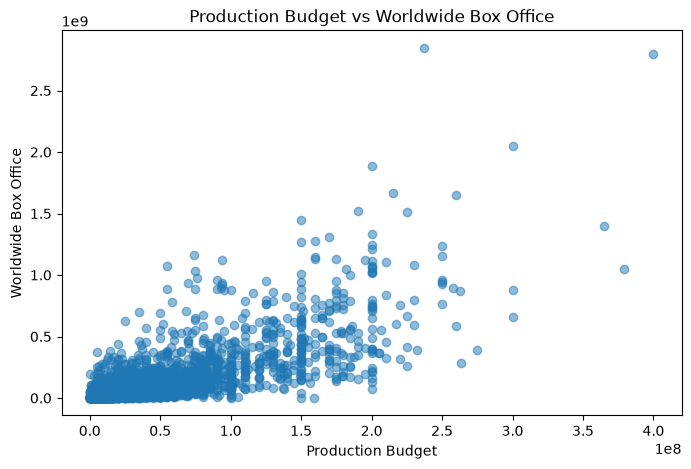

In [ ]:
# now we form a scatter plot to visualize

def plot_budget_vs_boxoffice(data):
    plt.figure(figsize=(8, 5))

    plt.scatter(
        data["production_budget"],
        data["worldwide_box_office"],
        alpha=0.5 # 50% for the transparency (ps 0 = invisbl; 1 = visible)
    )

    plt.xlabel("Production Budget")
    plt.ylabel("Worldwide Box Office")
    plt.title("Production Budget vs Worldwide Box Office")

    plt.show()


plot_budget_vs_boxoffice(budget_df)

The scatterplot shows positive association between these two.
Higher budget movies have higher worldwide box office, although there is a lot of variation.

<h3>H2: Movie runtime is significantly associated with worldwide box-office performance.</h3>

In [ ]:
# Now we get the needed query for H2

def get_runtime_data():
    query = """
    SELECT
        mc.runtime,
        ms.worldwide_box_office
    FROM Movie_Characteristics mc
    INNER JOIN Movie_Sales ms
        ON mc.movie_id = ms.movie_id
    WHERE mc.runtime IS NOT NULL
      AND ms.worldwide_box_office IS NOT NULL;
    """
# Return movies that have both runtime and worldwide box-office value
    return pd.read_sql(query, conn)


runtime_df = get_runtime_data()

print(runtime_df.head())
print("Number of movies:", len(runtime_df))

   runtime  worldwide_box_office
0      109            17865209.0
1      101            46060861.0
2      104            25044057.0
3       95            21596074.0
4      115            78269970.0
Number of movies: 4821


C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_16984\2890368377.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


In [9]:
get_runtime_data()

C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_16984\2890368377.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


,runtime,worldwide_box_office
0,109,17865209.0
1,101,46060861.0
2,104,25044057.0
3,95,21596074.0
4,115,78269970.0
...,...,...
4816,125,680.0
4817,107,639055.0
4818,81,54864.0
4819,95,6259122.0


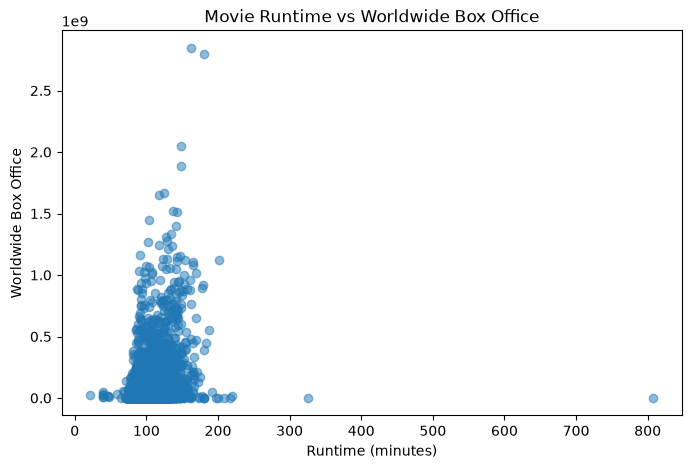

In [ ]:
# we form a scatter plot to vizualise

def plot_runtime_vs_boxoffice(data):
    plt.figure(figsize=(8, 5))

    plt.scatter(
        data["runtime"],
        data["worldwide_box_office"],
        alpha=0.5 # 50% for the transparency (ps 0 = invisbl; 1 = visible)
    )

    plt.xlabel("Runtime (minutes)")
    plt.ylabel("Worldwide Box Office")
    plt.title("Movie Runtime vs Worldwide Box Office")

    plt.show()


plot_runtime_vs_boxoffice(runtime_df)

Most runtimes are concentrated around 80–180 minutes, there are a few extreme values around 300–800 minutes.

<h3>H3: Worldwide box-office performance differs significantly across movie genres</h3>

In [ ]:
# Now we start with H3

# Because each movie can have multiple genres, we'll use your Movie_Genre bridge table

def get_genre_data():
    query = """
    SELECT
        g.genre_name,
        ms.worldwide_box_office
    FROM Movie_Genre mg
    INNER JOIN Genre g
        ON mg.genre_id = g.genre_id
    INNER JOIN Movie_Sales ms
        ON mg.movie_id = ms.movie_id
    WHERE ms.worldwide_box_office IS NOT NULL;
    """
    return pd.read_sql(query, conn)
# INNER JOIN here returns only movies that have matching records in all three tables

genre_df = get_genre_data()

print(genre_df.head())
print("Number of records:", len(genre_df))

  genre_name  worldwide_box_office
0     Action           108286422.0
1      Drama           108286422.0
2     Horror           108286422.0
3    Mystery           108286422.0
4     Sci-Fi           108286422.0
Number of records: 13380


C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_16984\2282129874.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


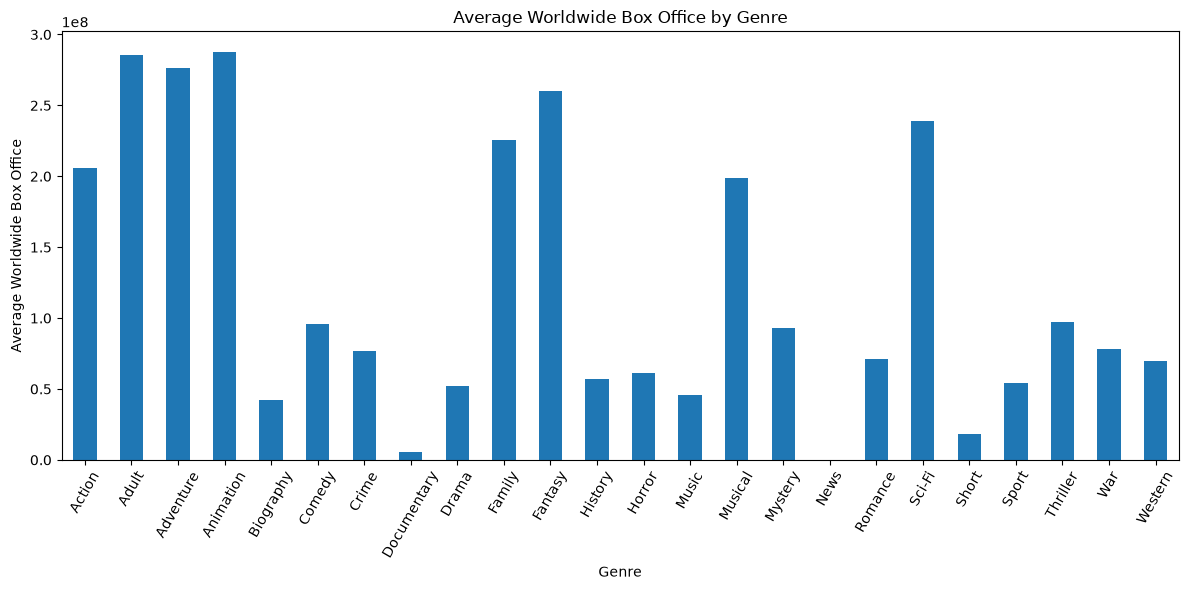

In [ ]:
# we form a Bar chart to vizualise

def plot_boxoffice_by_genre(data):
    genre_avg = data.groupby("genre_name")["worldwide_box_office"].mean()

    genre_avg.plot(kind="bar", figsize=(12, 6))

    plt.xlabel("Genre")
    plt.ylabel("Average Worldwide Box Office")
    plt.title("Average Worldwide Box Office by Genre")
    plt.xticks(rotation=60)
    plt.tight_layout()
    plt.show()


plot_boxoffice_by_genre(genre_df)

So, THis created Python encapsulator functions to retrieve the budget, runtime and genre data from PostgreSQL and visualize their relationship with worldwide box-office performance.